<a href="https://colab.research.google.com/github/rll/deepul/blob/master/homeworks/hw3/hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting Started

## Overview
This semester, all homeworks will be conducted through Google Colab notebooks. All code for the homework assignment will be written and run in this notebook. Running in Colab will automatically provide a GPU, but you may also run this notebook locally by following [these instructions](https://research.google.com/colaboratory/local-runtimes.html) if you wish to use your own GPU.

You will save images in the notebooks to use and fill out a given LaTeX template which will be submitted to Gradescope, along with your notebook code.

## Using Colab
On the left-hand side, you can click the different icons to see a Table of Contents of the assignment, as well as local files accessible through the notebook.

Make sure to go to **Runtime -> Change runtime type** and select **GPU** as the hardware accelerator. This allows you to use a GPU. Run the cells below to get started on the assignment. Note that a session is open for a maximum of 12 hours, and using too much GPU compute may result in restricted access for a short period of time. Please start the homework early so you have ample time to work.

**If you loaded this notebook from clicking "Open in Colab" from github, you will need to save it to your own Google Drive to keep your work.**

## General Tips
In each homework problem, you will implement a GAN model and run it on a dataset. We provide the expected outputs to help as a sanity check.

Feel free to print whatever output (e.g. debugging code, training code, etc) you want, as the graded submission will be the submitted pdf with images.

After you complete the assignment, download all of the image outputted in the results/ folder and upload them to the figure folder in the given latex template.

Run the cells below to download and load up the starter code.

In [20]:
# !if [ -d deepul ]; then rm -Rf deepul; fi
# !git clone https://github.com/rll/deepul.git 
# !pip install ./deepul

In [21]:
from deepul.hw3_helper import *
import deepul.pytorch_util as ptu
import warnings
warnings.filterwarnings('ignore')

In [22]:
ptu.set_gpu_mode(True)

# Question 1: Warmup [20pt]

In this question, we will train different variants of GANs on an easy 1D dataset. 

Execute the cell below to visualize our datasets.

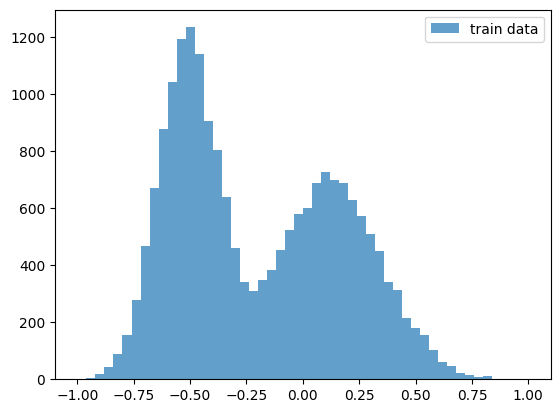

In [23]:
visualize_q1_dataset()

In [24]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
from scipy.stats import norm
from tqdm import trange, tqdm_notebook

## Part 1(a)
In this part, we'll train our generator and discriminator via the original minimax GAN objective:
<insert GAN Objective here>
$$min_{G} max_{D} \mathbb{E}_{x \sim p_{data}} [\log D(x)] + \mathbb{E}_{z \sim p(z)}[\log (1-D(G(z)))]$$

Use an MLP for both your generator and your discriminator, and train until the generated distribution resembles the target distribution. 
* 3 layers
* 128 hidden dim
* LeakyReLU nonlinearities with negative_slope=0.2

### Solution

In [25]:
class Generator(nn.Module):
    def __init__(self, latent_dim=10, hidden_dim=128, output_dim=1):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            
            nn.Linear(hidden_dim, output_dim),
            nn.Tanh()  # Output in [-1, 1]
        )

    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, output_dim=1):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

class GANTrainer:
    def __init__(self, latent_dim=10, hidden_dim=128, learning_rate=0.0002, batch_size=128, device=None, non_saturating=False):
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.device = device or torch.device("cpu")
        self.non_saturating = non_saturating
        
        # Initialize models
        self.generator = Generator(latent_dim, hidden_dim, 1).to(self.device)
        self.discriminator = Discriminator(1, hidden_dim, 1).to(self.device)
        
        # Initialize optimizers
        self.g_optimizer = torch.optim.Adam(
            self.generator.parameters(), 
            lr=learning_rate, 
            betas=(0.5, 0.999)
        )
        self.d_optimizer = torch.optim.Adam(
            self.discriminator.parameters(), 
            lr=learning_rate, 
            betas=(0.5, 0.999)
        )
        
        # Loss function
        self.criterion = nn.BCELoss()
        
        # Training history
        self.d_losses = []
        self.g_losses = []
    
    def create_dataloader(self, train_data):
        """Create DataLoader from training data"""
        train_tensor = torch.FloatTensor(train_data).to(self.device)
        train_dataset = data.TensorDataset(train_tensor)
        return data.DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
    
    def generate_samples(self, num_samples=5000):
        """Generate samples and discriminator outputs for evaluation"""
        with torch.no_grad():
            self.generator.eval()
            self.discriminator.eval()
            
            # Generate samples
            z = torch.randn(num_samples, self.latent_dim).to(self.device)
            samples = self.generator(z).detach().cpu().numpy()
            
            # Get discriminator outputs on test points
            test_points = torch.FloatTensor(np.linspace(-1, 1, 1000)).reshape(-1, 1).to(self.device)
            discriminator_outputs = self.discriminator(test_points).detach().cpu().numpy()
            
            return samples.flatten(), discriminator_outputs.flatten()
    
    def train_step(self, real_samples):
        """Single training step for both generator and discriminator"""
        current_batch_size = real_samples.size(0)
        
        # Set models to training mode
        self.discriminator.train()
        self.generator.train()
        
        # Create labels
        real_labels = torch.ones(current_batch_size, 1).to(self.device)
        fake_labels = torch.zeros(current_batch_size, 1).to(self.device)
        
        # ===== Train Discriminator =====
        self.d_optimizer.zero_grad()
        
        # Real samples
        real_outputs = self.discriminator(real_samples)
        d_real_loss = self.criterion(real_outputs, real_labels)
        
        # Fake samples
        z = torch.randn(current_batch_size, self.latent_dim).to(self.device)
        fake_samples = self.generator(z)
        fake_outputs = self.discriminator(fake_samples.detach())
        d_fake_loss = self.criterion(fake_outputs, fake_labels)
        
        # Total discriminator loss
        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.discriminator.parameters(), max_norm=1.0)
        self.d_optimizer.step()
        
        # ===== Train Generator =====
        self.g_optimizer.zero_grad()
        
        # Generate new fake samples for generator training
        z = torch.randn(current_batch_size, self.latent_dim).to(self.device)
        fake_samples = self.generator(z)
        fake_outputs = self.discriminator(fake_samples)
        
        # Generator loss - wants discriminator to classify fake as real
        if self.non_saturating:
            g_loss = self.criterion(fake_outputs, real_labels)
        else:
            g_loss = -self.criterion(fake_outputs, fake_labels)
        g_loss.backward()
        # clip gradient norm
        torch.nn.utils.clip_grad_norm_(self.generator.parameters(), max_norm=1.0)
        self.g_optimizer.step()
        
        return d_loss.item(), g_loss.item()
    
    def train(self, train_data, num_epochs=500, verbose=True):
        """Train the GAN"""
        train_loader = self.create_dataloader(train_data)
        
        # Storage for results
        epoch_1_samples = None
        epoch_1_discriminator_outputs = None
        
        for epoch in range(num_epochs):
            epoch_d_losses = []
            epoch_g_losses = []
            
            for real_samples, in train_loader:
                d_loss, g_loss = self.train_step(real_samples)
                
                self.d_losses.append(d_loss)
                epoch_d_losses.append(d_loss)
                epoch_g_losses.append(g_loss)
            
            # Save epoch 1 results
            if epoch == 0:
                epoch_1_samples, epoch_1_discriminator_outputs = self.generate_samples()
            
            # Print progress
            if verbose and (epoch + 1) % 10 == 0:
                avg_d_loss = np.mean(epoch_d_losses)
                avg_g_loss = np.mean(epoch_g_losses)
                print(f"Epoch {epoch+1}/{num_epochs}, Avg D loss: {avg_d_loss:.4f}, Avg G loss: {avg_g_loss:.4f}")
        
        # Generate final results
        final_samples, final_discriminator_outputs = self.generate_samples()
        linspace_array = np.linspace(-1, 1, 1000)
        
        return (
            np.array(self.d_losses),
            epoch_1_samples,
            linspace_array,
            epoch_1_discriminator_outputs,
            final_samples,
            linspace_array,
            final_discriminator_outputs
        )

In [26]:
def q1_a(train_data):
    """
    train_data: An (20000, 1) numpy array of floats in [-1, 1]

    Returns
    - a (# of training iterations,) numpy array of discriminator losses evaluated every minibatch
    - a numpy array of size (5000,) of samples drawn from your model at epoch #1
    - a numpy array of size (1000,) linearly spaced from [-1, 1]; hint: np.linspace
    - a numpy array of size (1000,), corresponding to the discriminator output (after sigmoid) 
        at each location in the previous array at epoch #1

    - a numpy array of size (5000,) of samples drawn from your model at the end of training
    - a numpy array of size (1000,) linearly spaced from [-1, 1]; hint: np.linspace
    - a numpy array of size (1000,), corresponding to the discriminator output (after sigmoid) 
        at each location in the previous array at the end of training
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # device = ('cuda ')
    trainer = GANTrainer(
        latent_dim=10,
        hidden_dim=128,
        learning_rate=0.0002,
        batch_size=128,
        device=device,
        non_saturating=False
    )
    
    return trainer.train(train_data, num_epochs=1000)

### Results

In [27]:
# q1_save_results('a', q1_a)

## Part 1(b)
Here, we'll use the non-saturating formulation of the GAN objective. Now, we have two separate objectives:
$$L^{(D)} = \mathbb{E}_{x \sim p_{data}} [\log D(x)] + \mathbb{E}_{z \sim p(z)}[\log (1-D(G(z)))]$$
$$L^{(G)} = - \mathbb{E}_{z \sim p(z)} \log(D(G(z)))$$

 ### Solution

In [28]:
def q1_b(train_data):
    """
    train_data: An (20000, 1) numpy array of floats in [-1, 1]

    Returns
    - a (# of training iterations,) numpy array of discriminator losses evaluated every minibatch
    - a numpy array of size (5000,) of samples drawn from your model at epoch #1
    - a numpy array of size (1000,) linearly spaced from [-1, 1]; hint: np.linspace
    - a numpy array of size (1000,), corresponding to the discriminator output (after sigmoid) 
        at each location in the previous array at epoch #1

    - a numpy array of size (5000,) of samples drawn from your model at the end of training
    - a numpy array of size (1000,) linearly spaced from [-1, 1]; hint: np.linspace
    - a numpy array of size (1000,), corresponding to the discriminator output (after sigmoid) 
        at each location in the previous array at the end of training
    """
    
    # device = torch.device("cpu")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trainer = GANTrainer(
        latent_dim=10,
        hidden_dim=128,
        learning_rate=0.0002,
        batch_size=128,
        device=device,
        non_saturating=True
    )
    
    return trainer.train(train_data, num_epochs=1000)

 ### Results

In [29]:
# q1_save_results('b', q1_b)

# Question 2: GANs on CIFAR-10 [35pt]

In this exercise, you will train a GAN on CIFAR-10. Execute the cell below to visualize the dataset. 

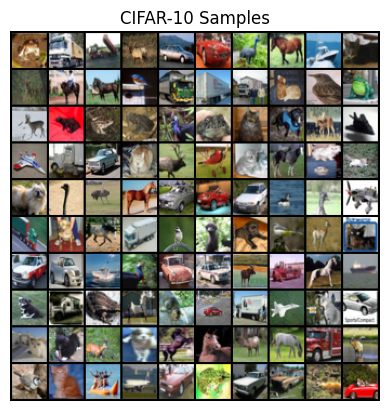

In [30]:
visualize_q2_data()

 We'll use the CIFAR-10 architecture from the [SN-GAN paper](https://arxiv.org/pdf/1802.05957.pdf) (see page 17), with $z \in \mathbb R ^{128}$, with $z \sim \mathcal N (0, I_{128})$. Instead of upsampling via transposed convolutions and downsampling via pooling or striding, we'll use these DepthToSpace and SpaceToDepth methods for changing the spatial configuration of our hidden states. 

```
class DepthToSpace(nn.Module):
    def __init__(self, block_size):
        super().__init__()
        self.block_size = block_size
        self.block_size_sq = block_size * block_size

    def forward(self, input):
        output = input.permute(0, 2, 3, 1)
        (batch_size, d_height, d_width, d_depth) = output.size()
        s_depth = int(d_depth / self.block_size_sq)
        s_width = int(d_width * self.block_size)
        s_height = int(d_height * self.block_size)
        t_1 = output.reshape(batch_size, d_height, d_width, self.block_size_sq, s_depth)
        spl = t_1.split(self.block_size, 3)
        stack = [t_t.reshape(batch_size, d_height, s_width, s_depth) for t_t in spl]
        output = torch.stack(stack, 0).transpose(0, 1).permute(0, 2, 1, 3, 4).reshape(batch_size, s_height, s_width,
                                                                                      s_depth)
        output = output.permute(0, 3, 1, 2)
        return output


class SpaceToDepth(nn.Module):
    def __init__(self, block_size):
        super().__init__()
        self.block_size = block_size
        self.block_size_sq = block_size * block_size

    def forward(self, input):
        output = input.permute(0, 2, 3, 1)
        (batch_size, s_height, s_width, s_depth) = output.size()
        d_depth = s_depth * self.block_size_sq
        d_width = int(s_width / self.block_size)
        d_height = int(s_height / self.block_size)
        t_1 = output.split(self.block_size, 2)
        stack = [t_t.reshape(batch_size, d_height, d_depth) for t_t in t_1]
        output = torch.stack(stack, 1)
        output = output.permute(0, 2, 1, 3)
        output = output.permute(0, 3, 1, 2)
        return output

# Spatial Upsampling with Nearest Neighbors
Upsample_Conv2d(in_dim, out_dim, kernel_size=(3, 3), stride=1, padding=1):
    x = torch.cat([x, x, x, x], dim=1)
    DepthToSpace(block_size=2)
    Conv2d(in_dim, out_dim, kernel_size, stride=stride, padding=padding)


# Spatial Downsampling with Spatial Mean Pooling
Downsample_Conv2d(in_dim, out_dim, kernel_size=(3, 3), stride=1, padding=1):
        SpaceToDepth(2)
        torch.sum(x.chunk(4, dim=1)) / 4.0
        nn.Conv2d(in_dim, out_dim, kernel_size,
                              stride=stride, padding=padding, bias=bias)
```

Here's pseudocode for how we'll implement a ResBlockUp, used in the generator:

```
ResnetBlockUp(x, in_dim, kernel_size=(3, 3), n_filters=256):
    _x = x
    _x = nn.BatchNorm2d(in_dim)(_x)
    _x = nn.ReLU()(_x)
    _x = nn.Conv2d(in_dim, n_filters, kernel_size, padding=1)(_x)
    _x = nn.BatchNorm2d(n_filters)(_x)
    _x = nn.ReLU()(_x)
    residual = Upsample_Conv2d(n_filters, n_filters, kernel_size, padding=1)(_x)
    shortcut = Upsample_Conv2d(in_dim, n_filters, kernel_size=(1, 1), padding=0)(x)
    return residual + shortcut
```
The ResBlockDown module is similar, except it uses Downsample_Conv2d and omits the BatchNorm.

Finally, here's the architecture for the generator:
```
def Generator(*, n_samples=1024, n_filters=128):
    z = Normal(0, 1)([n_samples, 128])
    nn.Linear(128, 4*4*256)
    reshape output of linear layer
    ResnetBlockUp(in_dim=256, n_filters=n_filters),
    ResnetBlockUp(in_dim=n_filters, n_filters=n_filters),
    ResnetBlockUp(in_dim=n_filters, n_filters=n_filters),
    nn.BatchNorm2d(n_filters),
    nn.ReLU(),
    nn.Conv2d(n_filters, 3, kernel_size=(3, 3), padding=1),
    nn.Tanh()
```
The discriminator (no BatchNorm!).
```
def Discriminator(*):
    def __init__(self, n_filters=128):
        ResnetBlockDown(3, n_filters=n_filters),
        ResnetBlockDown(128, n_filters=n_filters),
        ResBlock(n_filters, n_filters=n_filters),
        ResBlock(n_filters, n_filters=n_filters),
        nn.ReLU()
        global sum pooling
        nn.Linear(128, 1)
```


**Hyperparameters**

We'll implement [WGAN-GP](https://arxiv.org/abs/1704.00028), which uses a gradient penalty to regularize the discriminator. Use the Adam optimizer with $\alpha = 2e-4$, $\beta_1 = 0$, $\beta_2 = 0.9$, $\lambda = 10$, $n_{critic} = 5$. Use a batch size of 256 and n_filters=128 within the ResBlocks. Train for at least 25000 gradient steps, with the learning rate linearly annealed to 0 over training. 

**You will provide the following deliverables**
1. Inception score (CIFAR-10 version) of the final model. We provide a utility that will automatically do this for you.
2. Fréchet inception distance (bonus, 5pts)
3. Discriminator loss across training
4. 100 samples. 

## Solution

 ### Models

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import numpy as np
import os
from datetime import datetime

class DepthToSpace(nn.Module):
    def __init__(self, block_size: int):
        super().__init__()
        self.block_size = block_size
        self.block_size_squared = block_size ** 2
    
    def forward(self, input): # (B, C, H, W) -> (B, C/block_size^2, H*block_size, W*block_size)
        output = input.permute(0,2,3,1) # BCHW -> BHWC
        (b, h, w, c) = output.size() 
        s_depth = int(c / self.block_size_squared)
        s_width = int(w * self.block_size)
        s_height = int(h * self.block_size)
        t_1 = output.reshape(b, h, w, self.block_size_squared, s_depth)
        spl = t_1.split(self.block_size, 3) # (b, h, w, self.block_size, s_depth) * block_size
        stack = [t_t.reshape(b, h, s_width, s_depth) for t_t in spl] # (b, h, s_width, s_depth) * block_size
        output = torch.stack(stack, dim=0).transpose(0,1).permute(0,2,1,3,4).reshape(b, s_height, s_width, s_depth)
        return output.permute(0,3,1,2)

class SpaceToDepth(nn.Module):
    def __init__(self, block_size):
        super().__init__()
        self.block_size = block_size
        self.block_size_sq = block_size * block_size

    def forward(self, input):
        output = input.permute(0, 2, 3, 1) # (B, H, W, C)
        (batch_size, s_height, s_width, s_depth) = output.size()
        d_depth = s_depth * self.block_size_sq
        d_width = int(s_width / self.block_size)
        d_height = int(s_height / self.block_size)
        t_1 = output.split(self.block_size, 2)  # (B, H, block, C) * W/block
        stack = [t_t.reshape(batch_size, d_height, d_depth) for t_t in t_1]  # (B, H/block, C*block^2) * W/block
        output = torch.stack(stack, 1) # (B, W/block, H/block, C*block^2)
        output = output.permute(0, 2, 1, 3) #(B, H/block, W/block, C*block^2)
        output = output.permute(0, 3, 1, 2) # (B, C*block^2, H/block, W/block)
        return output

class Upsample_Conv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3,3), stride=(1,1), padding=(1,1)):
        super().__init__()
        self.depth2space = DepthToSpace(block_size=2)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        
    def forward(self, x):
        x = torch.cat([x, x, x, x], dim=1)
        x = self.depth2space(x)
        x = self.conv(x)
        return x
    
class ResBlock(nn.Module):
    def __init__(self, in_dim, kernel_size=(3,3), n_filters=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_dim, n_filters, kernel_size, padding=1)
        self.conv2 = nn.Conv2d(n_filters, n_filters, kernel_size, padding=1)
        self.shortcut = nn.Conv2d(in_dim, n_filters, kernel_size=(1,1), padding=0) if in_dim != n_filters else nn.Identity()
        
    def forward(self, x):
        _x = x
        _x = F.relu(_x)
        _x = self.conv1(_x)
        _x = F.relu(_x)
        _x = self.conv2(_x)
        shortcut = self.shortcut(x)
        return _x + shortcut
    
class Downsample_Conv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3,3), stride=(1,1), padding=(1,1)):
        super().__init__()
        self.space2depth = SpaceToDepth(block_size=2)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
    
    def forward(self, x):
        x = self.space2depth(x)
        chunks = x.chunk(4, dim=1)
        x = sum(chunks) / 4.0
        x = self.conv(x)
        return x

class ResnetBlockUp(nn.Module):
    def __init__(self, in_dim, kernel_size=(3,3), n_filters=64):
        super().__init__()
        self.batchnorm1 = nn.BatchNorm2d(in_dim)
        self.conv1 = nn.Conv2d(in_dim, n_filters, kernel_size, padding=1)
        self.batchnorm2 = nn.BatchNorm2d(n_filters)
        self.upscale_conv = Upsample_Conv2d(n_filters, n_filters, kernel_size, padding=1)
        self.shortcut = Upsample_Conv2d(in_dim, n_filters, kernel_size=(1,1), padding=0)
        
    def forward(self, x):
        _x = x
        _x = self.batchnorm1(_x)
        _x = F.relu(_x)
        _x = self.conv1(_x)
        _x = self.batchnorm2(_x)
        _x = F.relu(_x)
        _x = self.upscale_conv(_x)
        shortcut = self.shortcut(x)
        return _x + shortcut

class ResnetBlockDown(nn.Module):
    def __init__(self, in_dim, kernel_size=(3,3), n_filters=64):
        super().__init__()
        self.conv1 = nn.Conv2d(in_dim, n_filters, kernel_size, padding=1)
        self.downscale_conv = Downsample_Conv2d(n_filters, n_filters, kernel_size, padding=1)
        self.shortcut = Downsample_Conv2d(in_dim, n_filters, kernel_size=(1,1), padding=0)
    
    def forward(self, x):
        _x = x
        _x = F.relu(_x)
        _x = self.conv1(_x)
        _x = F.relu(_x)
        _x = self.downscale_conv(_x)
        shortcut = self.shortcut(x)
        return _x + shortcut

class WGANGPGenerator(nn.Module):
    def __init__(self, in_dim=128, n_filters=128):
        super().__init__()
        self.linear = nn.Linear(in_dim, 4*4*256) 
        self.resnet_blocks_1 = ResnetBlockUp(in_dim=256, n_filters=n_filters)
        self.resnet_blocks_2 = ResnetBlockUp(in_dim=n_filters, n_filters=n_filters)
        self.resnet_blocks_3 = ResnetBlockUp(in_dim=n_filters, n_filters=n_filters)
        self.batch_norm = nn.BatchNorm2d(n_filters)  # Fixed naming
        self.conv_out = nn.Conv2d(n_filters, 3, kernel_size=(3,3), padding=1)
    
    def forward(self, z):
        x = self.linear(z)
        x = x.view(-1, 256, 4, 4)
        x = self.resnet_blocks_1(x)
        x = self.resnet_blocks_2(x)
        x = self.resnet_blocks_3(x)
        x = self.batch_norm(x)
        x = F.relu(x)
        x = self.conv_out(x)
        x = F.tanh(x)
        return x

class WGANGPDiscriminator(nn.Module):
    def __init__(self, n_filters=128):
        super().__init__()
        self.resblock_down_1 = ResnetBlockDown(3, n_filters=n_filters)
        self.resblock_down_2 = ResnetBlockDown(n_filters, n_filters=n_filters)
        self.resblock_1 = ResBlock(n_filters, n_filters=n_filters)
        self.resblock_2 = ResBlock(n_filters, n_filters=n_filters)
        self.linear = nn.Linear(n_filters, 1)
    
    def forward(self, x):
        x = self.resblock_down_1(x)
        x = self.resblock_down_2(x)
        x = self.resblock_1(x)
        x = self.resblock_2(x)
        x = F.relu(x)
        x = x.sum(dim=(2, 3))  # Global sum pooling
        x = self.linear(x)
        return x

class WGANTrainer:
    def __init__(self, checkpoint_dir="checkpoints"):
        # Hyperparameters
        self.LEARNING_RATE = 2e-4
        self.BETA1 = 0.0
        self.BETA2 = 0.9
        self.LAMBDA_GP = 10  # Gradient penalty coefficient
        self.N_CRITIC = 5    # Number of critic updates per generator update
        self.BATCH_SIZE = 256
        self.N_FILTERS = 128
        self.TOTAL_STEPS = 25000
        self.latent_dim = 128
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Checkpoint directory
        self.checkpoint_dir = checkpoint_dir
        os.makedirs(checkpoint_dir, exist_ok=True)
        
        # Initialize models
        self.generator = WGANGPGenerator(n_filters=self.N_FILTERS).to(self.device)
        self.discriminator = WGANGPDiscriminator(n_filters=self.N_FILTERS).to(self.device)
        
        # Initialize optimizers
        self.optimizer_G = optim.Adam(self.generator.parameters(), lr=self.LEARNING_RATE, betas=(self.BETA1, self.BETA2))
        self.optimizer_D = optim.Adam(self.discriminator.parameters(), lr=self.LEARNING_RATE, betas=(self.BETA1, self.BETA2))

        # Learning rate schedulers
        self.scheduler_G = optim.lr_scheduler.LinearLR(self.optimizer_G, start_factor=1.0, end_factor=0.0, total_iters=self.TOTAL_STEPS)
        self.scheduler_D = optim.lr_scheduler.LinearLR(self.optimizer_D, start_factor=1.0, end_factor=0.0, total_iters=self.TOTAL_STEPS)
        
        # Training history
        self.d_losses = []
        self.g_losses = []
        self.current_step = 0
    
    def gradient_penalty(self, real_samples, fake_samples):
        """Compute gradient penalty for WGAN-GP"""
        batch_size = real_samples.size(0)
        alpha = torch.rand(batch_size, 1, 1, 1).to(self.device)
        interpolated = real_samples * alpha + fake_samples.detach() * (1 - alpha)
        interpolated.requires_grad_(True)

        outputs = self.discriminator(interpolated)
        gradients = torch.autograd.grad(outputs, interpolated,
                                        grad_outputs=torch.ones_like(outputs),
                                        create_graph=True,
                                        retain_graph=True,
                                        only_inputs=True)[0]
        gradient_norm = gradients.reshape(batch_size, -1).norm(2, dim=1)
        penalty = ((gradient_norm - 1) ** 2).mean()
        return penalty
    
    def transform_data(self, train_data):
        """Transform data to [-1, 1]"""
        return (train_data * 2) - 1
    
    def denormalize_data(self, train_data):
        """Denormalize data to [0, 1]"""
        return (train_data + 1) / 2
    
    def create_dataloader(self, train_data):
        """Create DataLoader from training data"""
        train_data = self.transform_data(train_data)
        train_tensor = torch.FloatTensor(train_data).to(self.device)
        train_dataset = data.TensorDataset(train_tensor)
        return data.DataLoader(train_dataset, batch_size=self.BATCH_SIZE, shuffle=True)
    
    def save_checkpoint(self, step):
        """Save model checkpoint"""
        checkpoint = {
            'step': step,
            'generator_state_dict': self.generator.state_dict(),
            'discriminator_state_dict': self.discriminator.state_dict(),
            'optimizer_G_state_dict': self.optimizer_G.state_dict(),
            'optimizer_D_state_dict': self.optimizer_D.state_dict(),
            'scheduler_G_state_dict': self.scheduler_G.state_dict(),
            'scheduler_D_state_dict': self.scheduler_D.state_dict(),
            'd_losses': self.d_losses,
            'g_losses': self.g_losses,
            'hyperparameters': {
                'LEARNING_RATE': self.LEARNING_RATE,
                'BETA1': self.BETA1,
                'BETA2': self.BETA2,
                'LAMBDA_GP': self.LAMBDA_GP,
                'N_CRITIC': self.N_CRITIC,
                'BATCH_SIZE': self.BATCH_SIZE,
                'N_FILTERS': self.N_FILTERS,
                'TOTAL_STEPS': self.TOTAL_STEPS,
                'latent_dim': self.latent_dim
            }
        }
        
        checkpoint_path = os.path.join(self.checkpoint_dir, f'checkpoint_step_{step}.pt')
        torch.save(checkpoint, checkpoint_path)
        print(f"Checkpoint saved at step {step}: {checkpoint_path}")
        
        # Also save as latest checkpoint
        latest_path = os.path.join(self.checkpoint_dir, 'latest_checkpoint.pt')
        torch.save(checkpoint, latest_path)
    
    def load_checkpoint(self, checkpoint_path):
        """Load model checkpoint"""
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        
        self.generator.load_state_dict(checkpoint['generator_state_dict'])
        self.discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
        self.optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
        self.optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
        self.scheduler_G.load_state_dict(checkpoint['scheduler_G_state_dict'])
        self.scheduler_D.load_state_dict(checkpoint['scheduler_D_state_dict'])
        
        self.d_losses = checkpoint['d_losses']
        self.g_losses = checkpoint['g_losses']
        self.current_step = checkpoint['step']
        
        print(f"Checkpoint loaded from step {self.current_step}")
        return checkpoint['step']
    
    def generate_samples(self, num_samples=1000):
        """Generate samples for evaluation"""
        with torch.no_grad():
            self.generator.eval()
            
            # Generate samples in batches to avoid memory issues
            all_samples = []
            batch_size = min(self.BATCH_SIZE, num_samples)
            
            for i in range(0, num_samples, batch_size):
                current_batch_size = min(batch_size, num_samples - i)
                z = torch.randn(current_batch_size, self.latent_dim).to(self.device)
                fake_samples = self.generator(z)
                
                # Denormalize and convert to numpy
                fake_samples = self.denormalize_data(fake_samples)
                fake_samples = torch.clamp(fake_samples, 0, 1)
                fake_samples = fake_samples.detach().cpu().numpy()
                all_samples.append(fake_samples)
            
            # Set back to training mode
            self.generator.train()
            
            return np.concatenate(all_samples, axis=0)
    
    def train(self, train_data, verbose=True, save_checkpoint_every=1000):
        """Train the GAN"""
        train_loader = self.create_dataloader(train_data)
        
        print(f"Starting training from step {self.current_step}")
        print(f"Device: {self.device}")
        print(f"Total steps: {self.TOTAL_STEPS}")
        print(f"Checkpoint will be saved every {save_checkpoint_every} steps")
        
        step = self.current_step
        
        while step < self.TOTAL_STEPS:
            for real_samples, in train_loader:
                if step >= self.TOTAL_STEPS:
                    break

                real_samples = real_samples.to(self.device)
                batch_size = real_samples.size(0)

                # Train Discriminator N_CRITIC times
                for critic_iter in range(self.N_CRITIC):
                    self.optimizer_D.zero_grad()
                    z = torch.randn(batch_size, self.latent_dim).to(self.device)
                    fake_samples = self.generator(z).detach()

                    # Discriminator scores
                    real_score = self.discriminator(real_samples)
                    fake_score = self.discriminator(fake_samples)

                    # Gradient penalty
                    gp = self.gradient_penalty(real_samples, fake_samples)

                    # Discriminator loss (Wasserstein loss + gradient penalty)
                    loss_D = -torch.mean(real_score) + torch.mean(fake_score) + self.LAMBDA_GP * gp

                    loss_D.backward()
                    self.optimizer_D.step()

                # Train Generator
                self.optimizer_G.zero_grad()
                z = torch.randn(batch_size, self.latent_dim).to(self.device)
                fake_samples = self.generator(z)
                fake_score = self.discriminator(fake_samples)

                # Generator loss (Wasserstein loss)
                loss_G = -torch.mean(fake_score)

                loss_G.backward()
                self.optimizer_G.step()

                # Update learning rates
                self.scheduler_G.step()
                self.scheduler_D.step()

                # Update training history
                self.d_losses.append(loss_D.item())
                self.g_losses.append(loss_G.item())

                step += 1
                self.current_step = step

                # Print progress
                if verbose and step % 100 == 0:
                    current_lr_g = self.scheduler_G.get_last_lr()[0]
                    current_lr_d = self.scheduler_D.get_last_lr()[0]
                    print(f"Step {step}/{self.TOTAL_STEPS}, D Loss: {loss_D.item():.4f}, G Loss: {loss_G.item():.4f}, LR_G: {current_lr_g:.6f}, LR_D: {current_lr_d:.6f}")

                # Save checkpoint
                if step % save_checkpoint_every == 0:
                    self.save_checkpoint(step)

        # Save final checkpoint
        self.save_checkpoint(step)
        
        # Generate final results
        print("Generating final samples...")
        samples = self.generate_samples(num_samples=1000)
        
        return (
            np.array(self.d_losses),
            samples
        )

In [32]:

def q2(train_data):
    """
    train_data: An (n_train, 3, 32, 32) numpy array of CIFAR-10 images with values in [0, 1]

    Returns
    - a (# of training iterations,) numpy array of WGAN critic train losses evaluated every minibatch
    - a (1000, 32, 32, 3) numpy array of samples from your model in [0, 1]. 
        The first 100 will be displayed, and the rest will be used to calculate the Inception score. 
    """
    trainer = WGANTrainer(checkpoint_dir="checkpoints")
    latest_checkpoint = os.path.join(trainer.checkpoint_dir, "latest_checkpoint.pt")
    if os.path.exists(latest_checkpoint):
        print("Loading latest checkpoint...")
        trainer.load_checkpoint(latest_checkpoint)
    else:
        print("No checkpoint found. Starting from scratch.")
    
    # Train
    d_losses, samples = trainer.train(train_data)
    
    # Ensure correct output format
    if samples.shape == (1000, 3, 32, 32):
        samples = samples.transpose(0, 2, 3, 1)
    
    return d_losses, samples

## Results

In [33]:
# q2_save_results(q2)

# Question 3 : Quantization with GANS [40pt]
In this question, you'll train a variants of the VQGAN model to learn a mapping between image and a discrete codebook. We will do this on the CIFAR10 dataset.

## Part a: Vanilla VQGAN [25]
[VQGAN](https://github.com/CompVis/taming-transformers) extends the ideas from VQVAE by adding an additional GAN loss. Review HW 2 for more details on VQVAE, and may use your code from HW 2 (or HW2 solutions) to help with this question. Conceptually, the training procedure is the same as VQVAE, but with the addition of a discriminator network and its training.

Following the original VQGAN paper, we will use a patch-based discriminator. Split the image into 8x8 patches, which will be then fed into the discriminator. For the discrimiator you can use an architecture similar to the one used in the previous questions.
```
def Discriminator(*, n_filters=128):
    split to 8x8 patches
    ResnetBlockDown(3, n_filters=n_filters),
    ResnetBlockDown(128, n_filters=n_filters),
    ResBlock(n_filters, n_filters=n_filters),
    ResBlock(n_filters, n_filters=n_filters),
    nn.ReLU()
    global sum pooling
    nn.Linear(128, 1)
```

**Loss function**
We will use the loss function of

$L = L_{VQ} + 0.1 L_{GAN} + 0.5 L_{perceptual} + L_2$

Where $L_{VQ}$ is the VQ objective, $L_{GAN}$ is the GAN loss, $L_{perceptual}$ is the perceptual loss. 

For pytorch users, we provide the LPIPS loss from the original taming transformers paper ([found here](https://github.com/CompVis/taming-transformers/blob/master/taming/modules/losses/lpips.py)). An example of using the LPIPS loss is found below. If you are using a different framework, feel free to use any off the shelf code, just make sure to cite where you take it from.

Instead of using the adaptive weight on the GAN loss, we will use a fixed weight of 0.1.
* train for at least 15 epochs
* use a codebook size of 1024
* use Adam with betas=(0.5, 0.9) and 0 weight decay for both optimizers
* use the non-saturating formulation of the GAN objective.

**You will provide the following deliverables**
1. Final L2 reconstruction loss
2. Discriminator loss across training
3. $L_{perceptual}$ loss across training
4. Training l2 loss across training
5. Validation l2 reconstruction loss across training, evaluated at the end of every epoch
6. 100 reconstructions of the validation set.

In [34]:
# example usage of the LPIPS loss
from deepul.hw3_utils.lpips import LPIPS
loss = LPIPS()
x = torch.zeros(4, 3, 32, 32)
print(loss(x, x).mean())

loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
tensor(0.)


In [35]:
class residual(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.residual_block = nn.Sequential(
            nn.BatchNorm2d(dim),
            nn.ReLU(),
            nn.Conv2d(dim, dim, 3, 1, 1),
            nn.BatchNorm2d(dim),
            nn.ReLU(),
            nn.Conv2d(dim, dim, 1, 1, 0)
        )
        
    def forward(self, x):
        return x + self.residual_block(x)

class VQVAE(nn.Module):
    def __init__(self, dim,K,D ):
        super().__init__()
        assert dim == D, f"Encoder output dim ({dim}) must match codebook dim ({D})"
        self.encoder_residual_1= residual(dim)
        self.encoder_residual_2= residual(dim)
        
        self.decoder_residual_1= residual(dim)
        self.decoder_residual_2= residual(dim)
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, dim, kernel_size=4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(dim),
            nn.ReLU(),
            nn.Conv2d(dim, dim, kernel_size=4, stride=2, padding=1),  # 8*8
            self.encoder_residual_1,
            self.encoder_residual_2,
        )
        
        self.decoder = nn.Sequential(
            self.decoder_residual_1,
            self.decoder_residual_2,
            nn.BatchNorm2d(dim),
            nn.ReLU(),
            nn.ConvTranspose2d(dim,dim,4,2,1), # 16*16
            nn.BatchNorm2d(dim),
            nn.ReLU(),
            nn.ConvTranspose2d(dim,3,4,2,1), # 32*32
        )
        
        self.codebook = nn.Embedding(K,D)
        nn.init.uniform_(self.codebook.weight, -1/K, 1/K)
    def encode(self,x):
        z_e = self.encoder(x)
        batch_size, channels, height, width = z_e.shape
        z_e_flat = z_e.permute(0, 2, 3, 1).contiguous()  # [B, H, W, C]
        z_e_flat = z_e_flat.view(-1, channels)  # [B*H*W, C]
        
        
        distances = torch.sum((z_e_flat.unsqueeze(1) - self.codebook.weight.unsqueeze(0))**2, dim=-1) 
        # z_e_flat -> [B*H*W, C] -> [B*H*W,1,  C]
        # self.codebook.weight.unsqueeze(0) -> [K, D] -> [1, K, D]
        # distances -> [B*H*W, K]
        
        k = torch.argmin(distances, dim=-1)  # [B*H*W]
        # k [B*H*W] -> [B*H*W, 1]
        z_q_flat = self.codebook(k)  # [B*H*W, D]
        z_q = z_q_flat.view(batch_size, height, width, -1).permute(0, 3, 1, 2).contiguous()  # Back to [B, C, H, W]
        
        z_q = z_e + (z_q - z_e).detach() # Straight-through estimator
        return z_e, z_q
        
    def decode(self, z_q):
        x_recon = self.decoder(z_q)
        return x_recon
    
    def forward(self, x):
        z_e, z_q = self.encode(x)
        
        x_recon = self.decode(z_q)
        
        return z_e, z_q , x_recon
    # Add this method to the VQVAE class to extract discrete tokens
    def get_tokens(self, x):
        """Extract discrete tokens from input images"""
        z_e = self.encoder(x)
        batch_size, channels, height, width = z_e.shape
        z_e_flat = z_e.permute(0, 2, 3, 1).contiguous()  # [B, H, W, C]
        z_e_flat = z_e_flat.view(-1, channels)  # [B*H*W, C]
        
        distances = torch.sum((z_e_flat.unsqueeze(1) - self.codebook.weight.unsqueeze(0))**2, dim=-1)
        tokens = torch.argmin(distances, dim=-1)  # [B*H*W]
        
        return tokens.view(batch_size, height, width)  # [B, H, W]

    def decode_tokens(self, tokens):
        """Decode discrete tokens back to images"""
        batch_size, height, width = tokens.shape
        z_q_flat = self.codebook(tokens.view(-1))  # [B*H*W, D]
        z_q = z_q_flat.view(batch_size, height, width, -1).permute(0, 3, 1, 2).contiguous()
        return self.decode(z_q)



In [36]:
class VQGAN_trainer:
    def __init__(self, train_loader, val_loader, reconstruct_loader, n_epochs = 10, checkpoint_path=None):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.vqvae = VQVAE(dim=128, K=1024, D=128).to(self.device)
        self.discriminator = WGANGPDiscriminator(n_filters=128).to(self.device)
        self.perceptual_loss = LPIPS().to(self.device)
        
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.reconstruct_loader = reconstruct_loader
        
        self.optimizer_vqvae = torch.optim.Adam(
            self.vqvae.parameters(), 
            betas=(0.5, 0.9), 
            weight_decay=0, 
            lr=2e-4
        )
        self.optimizer_discriminator = torch.optim.Adam(
            self.discriminator.parameters(), 
            betas=(0.5, 0.9), 
            weight_decay=0, 
            lr=2e-4
        )
        
        self.n_epochs = n_epochs
        self.checkpoint_path = checkpoint_path if checkpoint_path else "vqgan_checkpoint.pth"
        self.start_epoch = 0
        
        # Training loss tracking
        self.discriminator_losses = []
        self.l_pips_losses = []
        self.l2_recon_train = []
        self.l2_recon_test = []
        
        # Load checkpoint if it exists
        if os.path.exists(self.checkpoint_path):
            self.load_checkpoint()
    
    def save_checkpoint(self, epoch):
        """Save model checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'vqvae_state_dict': self.vqvae.state_dict(),
            'discriminator_state_dict': self.discriminator.state_dict(),
            'optimizer_vqvae_state_dict': self.optimizer_vqvae.state_dict(),
            'optimizer_discriminator_state_dict': self.optimizer_discriminator.state_dict(),
            'discriminator_losses': self.discriminator_losses,
            'l_pips_losses': self.l_pips_losses,
            'l2_recon_train': self.l2_recon_train,
            'l2_recon_test': self.l2_recon_test
        }
        torch.save(checkpoint, self.checkpoint_path)
        print(f"Checkpoint saved at epoch {epoch}")
    
    def load_checkpoint(self):
        """Load model checkpoint"""
        checkpoint = torch.load(self.checkpoint_path, map_location=self.device, weights_only=False)
        
        self.vqvae.load_state_dict(checkpoint['vqvae_state_dict'])
        self.discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
        self.optimizer_vqvae.load_state_dict(checkpoint['optimizer_vqvae_state_dict'])
        self.optimizer_discriminator.load_state_dict(checkpoint['optimizer_discriminator_state_dict'])
        
        self.start_epoch = checkpoint['epoch'] + 1
        self.discriminator_losses = checkpoint['discriminator_losses']
        self.l_pips_losses = checkpoint['l_pips_losses']
        self.l2_recon_train = checkpoint['l2_recon_train']
        self.l2_recon_test = checkpoint['l2_recon_test']
        
        print(f"Checkpoint loaded, resuming from epoch {self.start_epoch}")
        
    def compute_VQ_loss(self, x, recon_x, z_e, z_q):
        """Compute VQ-VAE losses"""
        recon_loss = F.mse_loss(recon_x, x)
        vq_loss = F.mse_loss(z_q.detach(), z_e)  # Move codebook towards encoder
        commit_loss = F.mse_loss(z_e, z_q.detach())  # Commit encoder to codebook
        
        return recon_loss + vq_loss + 0.25 * commit_loss
    
    def gradient_penalty(self, real_samples, fake_samples):
        """Compute gradient penalty for WGAN-GP"""
        batch_size = real_samples.size(0)
        alpha = torch.rand(batch_size, 1, 1, 1).to(self.device)
        interpolated = real_samples * alpha + fake_samples.detach() * (1 - alpha)
        interpolated.requires_grad_(True)

        outputs = self.discriminator(interpolated)
        gradients = torch.autograd.grad(
            outputs, interpolated,
            grad_outputs=torch.ones_like(outputs),
            create_graph=True,
            retain_graph=True,
            only_inputs=True
        )[0]
        
        gradient_norm = gradients.reshape(batch_size, -1).norm(2, dim=1)
        penalty = ((gradient_norm - 1) ** 2).mean()
        return penalty
    
    def compute_adversarial_loss(self, x):
        """Compute adversarial loss for generator"""
        discriminator_logits = self.discriminator(x)
        return -torch.mean(discriminator_logits)

    def compute_final_loss(self, x, recon_x, z_e, z_q):
        """Compute total loss for VQVAE"""
        vq_loss = self.compute_VQ_loss(x, recon_x, z_e, z_q)
        adversarial_loss = self.compute_adversarial_loss(recon_x)
        perceptual_loss = self.perceptual_loss(x, recon_x).mean()
        l2_recon_loss = F.mse_loss(recon_x, x)

        total_loss = vq_loss + 0.1 * adversarial_loss + 0.5 * perceptual_loss + l2_recon_loss
        
        return total_loss, adversarial_loss, perceptual_loss, l2_recon_loss
    
    def evaluate_VQGAN(self, data_loader, epoch):
        """Evaluate VQGAN on validation set"""
        total_loss = 0 
        n_batches = 0
        
        self.vqvae.eval()
        with torch.no_grad():
            for batch in data_loader:
                x = batch[0].to(self.device)
                z_e, z_q, recon_x = self.vqvae(x)
                
                recon_loss = F.mse_loss(recon_x, x)
                total_loss += recon_loss.item()
                n_batches += 1 
        
        avg_loss = total_loss / n_batches
        self.l2_recon_test.append(avg_loss)
        print(f"L2 Recon Loss on val set after epoch {epoch}: {avg_loss:.4f}")

    def train_VQGAN(self):
        """Train VQGAN model"""
        from tqdm import tqdm
        import os
        
        self.vqvae.train()
        self.discriminator.train()
        
        for epoch in range(self.start_epoch, self.n_epochs):
            adversarial_losses = []
            perceptual_losses = []
            l2_recon_losses = []
            
            # Add tqdm progress bar for batches
            progress_bar = tqdm(enumerate(self.train_loader), total=len(self.train_loader), 
                              desc=f'Epoch {epoch+1}/{self.n_epochs}')
            
            for batch_idx, batch in progress_bar:
                x = batch[0].to(self.device)
                
                # Train VQVAE
                z_e, z_q, recon_x = self.vqvae(x)
                vqvae_loss, adversarial_loss, perceptual_loss, l2_recon_loss = self.compute_final_loss(x, recon_x, z_e, z_q)
                
                adversarial_losses.append(adversarial_loss.item())
                perceptual_losses.append(perceptual_loss.item())
                l2_recon_losses.append(l2_recon_loss.item())
                
                self.optimizer_vqvae.zero_grad()
                vqvae_loss.backward()
                self.optimizer_vqvae.step()
                
                # Train Discriminator
                self.optimizer_discriminator.zero_grad()
                
                # Generate fake samples without gradients for VQVAE
                with torch.no_grad():
                    z_e, z_q, recon_x = self.vqvae(x)
                
                fake_logits = self.discriminator(recon_x)
                fake_loss = torch.mean(fake_logits)
                
                real_logits = self.discriminator(x)
                real_loss = -torch.mean(real_logits)
                
                discriminator_loss = real_loss + fake_loss + 10 * self.gradient_penalty(x, recon_x)
                
                discriminator_loss.backward()
                self.optimizer_discriminator.step()
                
                # Update progress bar with current losses
                progress_bar.set_postfix({
                    'Adv': f'{adversarial_loss.item():.4f}',
                    'Perc': f'{perceptual_loss.item():.4f}',
                    'L2': f'{l2_recon_loss.item():.4f}',
                    'Disc': f'{discriminator_loss.item():.4f}'
                })
                
            # Track epoch losses
            epoch_adversarial_loss = np.mean(adversarial_losses)
            epoch_perceptual_loss = np.mean(perceptual_losses)
            epoch_l2_recon_loss = np.mean(l2_recon_losses)
            
            self.discriminator_losses.append(epoch_adversarial_loss)
            self.l_pips_losses.append(epoch_perceptual_loss)
            self.l2_recon_train.append(epoch_l2_recon_loss)
            
            print(f"Epoch {epoch} - Adversarial Loss: {epoch_adversarial_loss:.4f}, "
                  f"Perceptual Loss: {epoch_perceptual_loss:.4f}, "
                  f"L2 Recon Loss: {epoch_l2_recon_loss:.4f}")
            
            # Evaluate on validation set
            self.evaluate_VQGAN(self.val_loader, epoch)
            
            # Save checkpoint after each epoch
            self.save_checkpoint(epoch)
    
    def reconstruct(self, data_loader):
        """Generate reconstructions from the model"""
        self.vqvae.eval()
        reconstructions = []
        
        with torch.no_grad():
            for batch in data_loader:
                x = batch[0].to(self.device)
                z_e, z_q, recon_x = self.vqvae(x)
                recon_x = torch.clamp(recon_x, 0, 1)
                recon_x = recon_x.detach().cpu()
                recon_x = recon_x.permute(0, 2, 3, 1)
                reconstructions.append(recon_x)
                
        # Concatenate all batches
        reconstructions = torch.cat(reconstructions, dim=0)
        return reconstructions.numpy()

In [49]:
from torch.utils.data import DataLoader, TensorDataset

def q3a(train_data, val_data, reconstruct_data):
    """
    train_data: An (n_train, 3, 32, 32) numpy array of CIFAR-10 images with values in [0, 1]
    val_data: An (n_train, 3, 32, 32) numpy array of CIFAR-10 images with values in [0, 1]
    reconstruct_data: An (100, 3, 32, 32) numpy array of CIFAR-10 images with values in [0, 1]. To be used for reconstruction

    Returns
    - a (# of training iterations,) numpy array of the discriminator train losses evaluated every minibatch
    - None or a (# of training iterations,) numpy array of the perceptual train losses evaluated every minibatch
    - a (# of training iterations,) numpy array of the l2 reconstruction evaluated every minibatch
    - a (# of epochs + 1,) numpy array of l2 reconstruction loss evaluated once at initialization and after each epoch on the val_data
    - a (100, 32, 32, 3) numpy array of reconstructions from your model in [0, 1] on the reconstruct_data.  
    """

    """ YOUR CODE HERE """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    train_tensor = torch.FloatTensor(train_data) 
    val_tensor = torch.FloatTensor(val_data) 
    reconstruct_tensor = torch.FloatTensor(reconstruct_data)

    train_dataset = TensorDataset(train_tensor)
    val_dataset = TensorDataset(val_tensor)
    reconstruct_dataset = TensorDataset(reconstruct_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    reconstruct_loader = DataLoader(reconstruct_dataset, batch_size=128, shuffle=False)
    
    discriminator_losses = []
    l_pips_losses = []
    l2_recon_train = []
    l2_recon_test = []
    reconstructions = []
    
    
    trainer = VQGAN_trainer(train_loader, val_loader, reconstruct_loader, n_epochs = 1, checkpoint_path = "vanila_gan_checkpoint.pth")
    trainer.train_VQGAN()
    
    discriminator_losses = trainer.discriminator_losses
    l_pips_losses = trainer.l_pips_losses
    l2_recon_train = trainer.l2_recon_train
    l2_recon_test = trainer.l2_recon_test
    reconstructions = trainer.reconstruct(reconstruct_loader)
    
    return discriminator_losses, l_pips_losses, l2_recon_train, l2_recon_test, reconstructions

loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
Checkpoint loaded, resuming from epoch 100


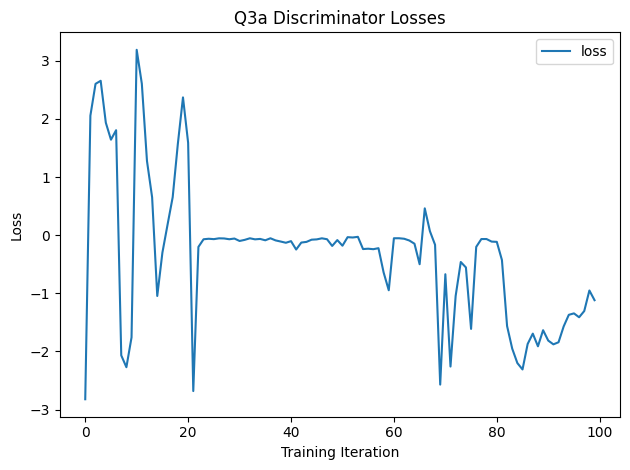

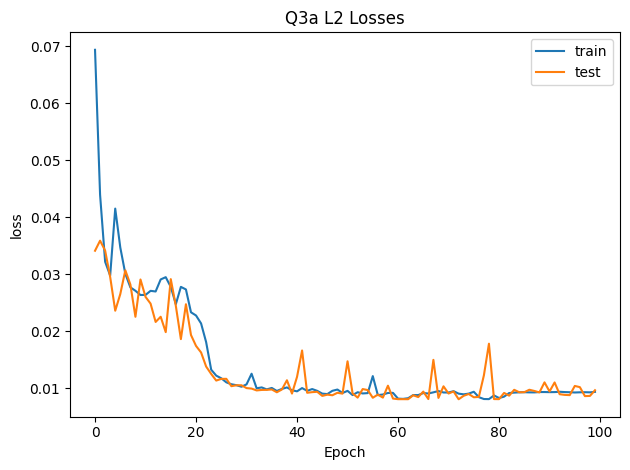

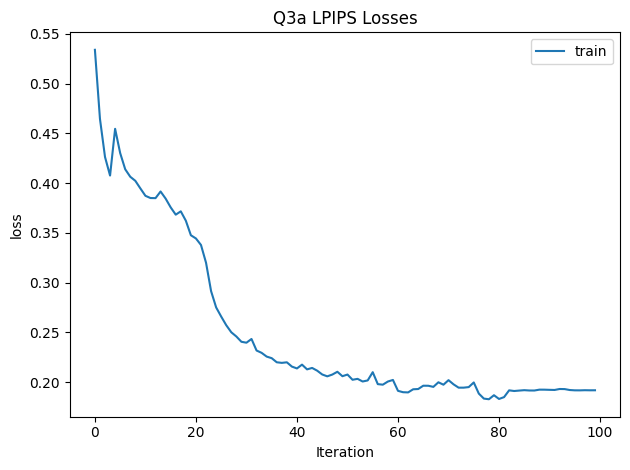

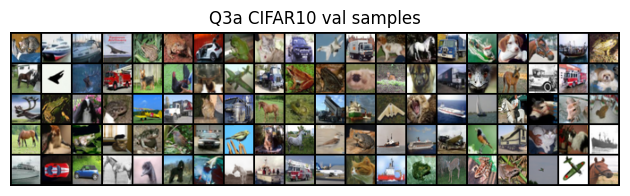

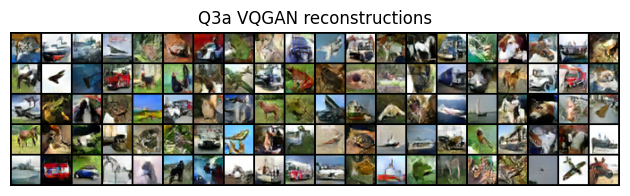

final_val_reconstruction_loss: 0.009687830177936584


In [50]:
q3_save_results(q3a, "a") 

## Part b: VIT-VQGAN [15]
In this part, you will replace the encoder and decoder in the VQGAN with a Vision Transformer (ViT) following the [Improved VQGAN paper](https://arxiv.org/abs/2110.04627). You may use pre-built ViT modules and/or transformers libraries for the purposes of this exercise. Split images into 4x4 patches which should give you 8x8 patches for each image.

**Discriminator**
In ViT-VQGAN, the patch-based discriminator is replaced with a full StyleGAN discriminator. For the purposes of this exercise, you should use the same discrimiator as described in part a but without splitting into patches. In addition add [spectral normalization](https://pytorch.org/docs/stable/generated/torch.nn.utils.spectral_norm.html#torch-nn-utils-spectral-norm) to all the conv and linear layers and use LeakyReLU instead of ReLU, following [SN-GANs](https://arxiv.org/abs/1802.05957). This is to help with training stability.
```
def Discriminator(*, n_filters=128):
    # all conv layers in the ResBlocks should have spectral normalization
    ResnetBlockDown(3, n_filters=n_filters),
    ResnetBlockDown(128, n_filters=n_filters),
    ResBlock(n_filters, n_filters=n_filters),
    ResBlock(n_filters, n_filters=n_filters),
    nn.LeakyReLU()
    global sum pooling
    nn.Linear(128, 1)
```
* in addition add 

**Loss function**
$L = L_{VQ} + 0.1 L_{GAN} + \alpha L_{perceptual} + L_2 + 0.1 L_1$

The ViT-VQGAN paper introduces a new loss term $L_{Logit\_laplace}$ which is a logit laplace loss. For simplicity, we will use an L1 loss instead.

If you implemented the perceptual loss in the previous part, you can use the same perceptual loss here, otherwise you may keep $\alpha = 0$.


You should be able to largely be able to reuse your implementations in the previous part for this problem
The only 3 updates you need are:
* use ViT for encoder and decoder of VQVAE, use 4 layers, 8 heads, and 256 for the embedding size 
* add L1 loss
* change the discrimiator to look at the full image

**You will provide the following deliverables**
1. Final L2 reconstruction loss
2. Discriminator loss across training
3. $L_{perceptual}$ loss across training
4. Training l2 loss across training
5. Validation l2 reconstruction loss across training, evaluated at the end of every epoch
6. 100 reconstructions of the validation set.


### Style gan


In [51]:
class StyleGANDiscriminator(nn.Module):
    def __init__(self, input_channels=3, input_size=32):
        super().__init__()
        
        # Progressive downsampling layers
        # 32x32 -> 16x16
        self.conv1 = nn.utils.spectral_norm(nn.Conv2d(input_channels, 64, 4, 2, 1))
        # 16x16 -> 8x8  
        self.conv2 = nn.utils.spectral_norm(nn.Conv2d(64, 128, 4, 2, 1))
        self.bn2 = nn.BatchNorm2d(128)
        # 8x8 -> 4x4
        self.conv3 = nn.utils.spectral_norm(nn.Conv2d(128, 256, 4, 2, 1))
        self.bn3 = nn.BatchNorm2d(256)
        # 4x4 -> 2x2
        self.conv4 = nn.utils.spectral_norm(nn.Conv2d(256, 512, 4, 2, 1))
        self.bn4 = nn.BatchNorm2d(512)
        # 2x2 -> 1x1
        self.conv5 = nn.utils.spectral_norm(nn.Conv2d(512, 1, 2, 1, 0))
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        # Progressive downsampling with LeakyReLU activation
        x = F.leaky_relu(self.conv1(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.bn4(self.conv4(x)), 0.2)
        x = self.dropout(x)
        # Final output layer
        x = self.conv5(x)
        
        return x.view(x.size(0), -1)  # Flatten to (batch_size, 1)

In [52]:
def masked_softmax(X, valid_lens):  #@save
    """Perform softmax operation by masking elements on the last axis."""
    def _sequence_mask(X, valid_len, value=0):
        maxlen = X.size(1)
        mask = torch.arange((maxlen), dtype=torch.float32,
                            device=X.device)[None, :] < valid_len[:, None] # all the postition >= valid_len are False
        X[~mask] = value # where the mask is False, set to value
        return X

    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        X = _sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, num_hiddens):
        super().__init__()
        def _make_tuple(x):
            if not isinstance(x, (list, tuple)):
                return (x, x)
            return x
        img_size, patch_size = _make_tuple(img_size), _make_tuple(patch_size)
        self.num_patches = (img_size[0] // patch_size[0]) * (
            img_size[1] // patch_size[1]) # num_patches = 32//4 * 32//4 = 64
        self.conv = nn.LazyConv2d(num_hiddens, kernel_size=patch_size, # kernel_size = 4 ->
                                  stride=patch_size)

    def forward(self, X):
        # Output shape: (batch size, no. of patches, no. of channels)
        X = self.conv(X).flatten(2).transpose(1, 2)
        return X

class DotProductAttention(nn.Module):  
    """Scaled dot product attention."""
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # Swap the last two dimensions of keys with keys.transpose(1, 2)
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d) # (batch_size, d,d)
        self.attention_weights = masked_softmax(scores, valid_lens) #( batch_size, d,d)
        return torch.bmm(self.dropout(self.attention_weights), values) # batch_size, h_dim, h_dim
    
class MultiHeadAttention(nn.Module):  
    """Multi-head attention."""
    def __init__(self, num_hiddens, num_heads, dropout, bias=False, **kwargs):
        super().__init__()
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_k = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_v = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_o = nn.LazyLinear(num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        queries = self.transpose_qkv(self.W_q(queries))
        keys = self.transpose_qkv(self.W_k(keys))
        values = self.transpose_qkv(self.W_v(values))

        if valid_lens is not None:
            # On axis 0, copy the first item (scalar or vector) for num_heads
            # times, then copy the next item, and so on
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        output = self.attention(queries, keys, values, valid_lens)
        output_concat = self.transpose_output(output)
        return self.W_o(output_concat)
    
    def transpose_qkv(self, X):
        """Transposition for parallel computation of multiple attention heads."""
        X = X.reshape(X.shape[0], X.shape[1], self.num_heads, -1)
        X = X.permute(0, 2, 1, 3)
        return X.reshape(-1, X.shape[2], X.shape[3])
    
    def transpose_output(self, X):
        """Reverse the operation of transpose_qkv."""
        X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2]) # (batch_size, num_heads, seq_len, num_hiddens / num_heads)
        X = X.permute(0, 2, 1, 3) # (batch_size, seq_len, num_heads, num_hiddens / num_heads)
        return X.reshape(X.shape[0], X.shape[1], -1) # (batch_size, seq_len, num_hiddens)



class ViTMLP(nn.Module):
    def __init__(self, mlp_num_hiddens, mlp_num_outputs, dropout=0.5):
        super().__init__()
        self.dense1 = nn.LazyLinear(mlp_num_hiddens)
        self.gelu = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)
        self.dense2 = nn.LazyLinear(mlp_num_outputs)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout2(self.dense2(self.dropout1(self.gelu(
            self.dense1(x)))))
        
class ViTBlock(nn.Module):
    def __init__(self, num_hiddens, norm_shape, mlp_num_hiddens,
                 num_heads, dropout, use_bias=False):
        super().__init__()
        self.ln1 = nn.LayerNorm(norm_shape)
        self.attention = MultiHeadAttention(num_hiddens, num_heads,
                                                dropout, use_bias)
        self.ln2 = nn.LayerNorm(norm_shape)
        self.mlp = ViTMLP(mlp_num_hiddens, num_hiddens, dropout)

    def forward(self, X, valid_lens=None):
        X = X + self.attention(*([self.ln1(X)] * 3), valid_lens)
        return X + self.mlp(self.ln2(X))
  
class MultiHeadAttention(nn.Module):  #@save
    """Multi-head attention."""
    def __init__(self, num_hiddens, num_heads, dropout, bias=False, **kwargs):
        super().__init__()
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_k = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_v = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_o = nn.LazyLinear(num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        queries = self.transpose_qkv(self.W_q(queries))
        keys = self.transpose_qkv(self.W_k(keys))
        values = self.transpose_qkv(self.W_v(values))

        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        output = self.attention(queries, keys, values, valid_lens)
        output_concat = self.transpose_output(output)
        return self.W_o(output_concat)
    
    def transpose_qkv(self, X):
        """Transposition for parallel computation of multiple attention heads."""
        X = X.reshape(X.shape[0], X.shape[1], self.num_heads, -1)
        X = X.permute(0, 2, 1, 3)
        return X.reshape(-1, X.shape[2], X.shape[3])
    
    def transpose_output(self, X):
        """Reverse the operation of transpose_qkv."""
        X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2]) # (batch_size, num_heads, seq_len, num_hiddens / num_heads)
        X = X.permute(0, 2, 1, 3) # (batch_size, seq_len, num_heads, num_hiddens / num_heads)
        return X.reshape(X.shape[0], X.shape[1], -1) # (batch_size, seq_len, num_hiddens)
Discriminator = StyleGANDiscriminator # alias

In [53]:
class ViTMLP(nn.Module):
    def __init__(self, mlp_num_hiddens, mlp_num_outputs, dropout=0.5):
        super().__init__()
        self.dense1 = nn.LazyLinear(mlp_num_hiddens)
        self.gelu = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)
        self.dense2 = nn.LazyLinear(mlp_num_outputs)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout2(self.dense2(self.dropout1(self.gelu(
            self.dense1(x)))))
        
class ViTBlock(nn.Module):
    def __init__(self, num_hiddens, norm_shape, mlp_num_hiddens,
                 num_heads, dropout, use_bias=False):
        super().__init__()
        self.ln1 = nn.LayerNorm(norm_shape)
        self.attention = MultiHeadAttention(num_hiddens, num_heads,
                                                dropout, use_bias)
        self.ln2 = nn.LayerNorm(norm_shape)
        self.mlp = ViTMLP(mlp_num_hiddens, num_hiddens, dropout)

    def forward(self, X, valid_lens=None):
        X = X + self.attention(*([self.ln1(X)] * 3), valid_lens)
        return X + self.mlp(self.ln2(X))

In [54]:
import torch
import torch.nn as nn
from einops.layers.torch import Rearrange

class ViT_Encoder(nn.Module):
    """Vision Transformer encoder for ViT-VQGAN following paper specifications."""
    def __init__(self, img_size, patch_size, num_hiddens, mlp_num_hiddens,
                 num_heads, num_blks, emb_dropout, blk_dropout,
                 use_bias=False):
        super().__init__()
        
        self.patch_embedding = PatchEmbedding(img_size, patch_size, num_hiddens)
        num_steps = self.patch_embedding.num_patches
        
        # Positional embedding initialization
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_steps, num_hiddens))
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)
        
        self.dropout = nn.Dropout(emb_dropout)
        
        # Transformer blocks
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", ViTBlock(
                num_hiddens, num_hiddens,
                mlp_num_hiddens, num_heads, blk_dropout, use_bias))
        
        # Pre-normalization
        self.norm = nn.LayerNorm(num_hiddens)
        
        # Two-layer FFN 
        self.head = nn.Sequential(
            nn.Linear(num_hiddens, num_hiddens),
            nn.GELU(),
            nn.Linear(num_hiddens, num_hiddens)
        )

    def forward(self, X):  # input (batch_size, 3, 32, 32)
        X = self.patch_embedding(X)  # (bs, 64, 256) - 8x8 patches for 32x32 image with 4x4 patch size
        X = self.dropout(X + self.pos_embedding)  # (bs, 64, 256)
        # Process through transformer blocks
        for blk in self.blks:
            X = blk(X)  # (bs, 64, 256)
        # Apply normalization and head
        X = self.norm(X)  # (bs, 64, 256)
        X = self.head(X)  # (bs, 64, 256)
        
        return X
            
class ViT_Decoder(nn.Module):
    """Vision Transformer decoder for ViT-VQGAN following paper specifications."""
    def __init__(self, img_size, patch_size, num_hiddens, mlp_num_hiddens,
                 num_heads, num_blks, emb_dropout, blk_dropout,
                 use_bias=False):
        super().__init__()
        
        # Positional embedding initialization
        self.pos_embedding = nn.Parameter(
            torch.zeros(1, (img_size // patch_size)**2, num_hiddens))
        
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)
        
        self.dropout = nn.Dropout(emb_dropout)
        
        # Transformer blocks
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", ViTBlock(
                num_hiddens, num_hiddens, mlp_num_hiddens,
                num_heads, blk_dropout, use_bias))
        
        # Pre-normalization
        self.norm = nn.LayerNorm(num_hiddens)
        
        # Two-layer FFN with tanh before pixel conversion
        self.pre_pixel = nn.Sequential(
            nn.Linear(num_hiddens, num_hiddens),
            nn.Tanh(),
            nn.Linear(num_hiddens, num_hiddens)
        )
        
        # Convert from patch tokens back to image
        self.to_pixel = nn.Sequential(
            # Reshape from sequence to spatial: (bs, 64, 256) -> (bs, 256, 8, 8)
            Rearrange('b (h w) c -> b c h w', 
                     h=img_size//patch_size, w=img_size//patch_size),
            # Upsample from patches back to full image: (bs, 256, 8, 8) -> (bs, 3, 32, 32)
            nn.ConvTranspose2d(num_hiddens, 3, 
                             kernel_size=patch_size, stride=patch_size),
            # Sigmoid activation for decoder output
            nn.Sigmoid()
        )

    def forward(self, X):  # input (batch_size, 64, 256) - patch tokens
        X = self.dropout(X + self.pos_embedding)  # (bs, 64, 256)
        
        # Process through transformer blocks
        for blk in self.blks:
            X = blk(X)  # (bs, 64, 256)
        
        # Apply normalization and pre-pixel FFN
        X = self.norm(X)  # (bs, 64, 256)
        X = self.pre_pixel(X)  # (bs, 64, 256)
        
        # Convert to pixels
        X = self.to_pixel(X)  # (bs, 3, 32, 32)
        
        return X
    
class ViT_VQGAN(nn.Module):
    def __init__(self, img_size=32, patch_size=4, num_hiddens=256, mlp_num_hiddens=256, 
                 num_heads=8, num_blks=4, emb_dropout=0.1, blk_dropout=0.1, use_bias=False):
        super().__init__()
        D = 32
        K = 1024
        
        self.encoder = ViT_Encoder(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
                                   num_blks, emb_dropout, blk_dropout, use_bias)
        
        self.decoder = ViT_Decoder(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
                                   num_blks, emb_dropout, blk_dropout, use_bias)
        
        self.codebook = nn.Embedding(K, D)
        
        self.linear_proj_encoder = nn.Linear(num_hiddens, D) 
        self.linear_proj_decoder = nn.Linear(D, num_hiddens)
        
        # Initialize codebook with normal distribution for l2 normalization
        nn.init.normal_(self.codebook.weight, mean=0.0, std=1.0)


    def encode(self, x):  # (B, 3, 32, 32)
        z_e = self.encoder(x)  # (B, 64, 256)
        z_e_compress = self.linear_proj_encoder(z_e)  # (B, 64, 32)
        
        # Apply l2 normalization to encoded latent variables
        z_e_compress = F.normalize(z_e_compress, p=2, dim=-1)
        
        batch_size, seq_len, compress_shape = z_e_compress.shape
        z_e_flat = z_e_compress.view(-1, compress_shape)  # [B*seq_len, D]
        
        # Apply l2 normalization to codebook vectors
        codebook_normalized = F.normalize(self.codebook.weight, p=2, dim=-1)
        
        # Find nearest codebook vectors using cosine similarity (l2 normalized distance)
        distances = torch.sum((z_e_flat.unsqueeze(1) - codebook_normalized.unsqueeze(0))**2, dim=-1) 
        k = torch.argmin(distances, dim=-1)  # [B*seq_len]
        
        # Get quantized vectors (l2 normalized)
        z_q_flat = codebook_normalized[k]  # [B*seq_len, D]
        z_q_compress = z_q_flat.view(batch_size, seq_len, compress_shape).contiguous()  # [B, seq_len, D]
        
        # Apply straight-through estimator for gradients
        z_q_compress = z_e_compress + (z_q_compress - z_e_compress).detach()
        
        # Project back to full dimensionality
        z_q = self.linear_proj_decoder(z_q_compress)  # (B, 64, 256)
        return z_e_compress, z_q_compress, z_q
        
    def decode(self, z_q):  # (B, 64, 256)
        recon_x = self.decoder(z_q)  # (B, 3, 32, 32)
        return recon_x
    
    def forward(self, x):
        z_e_compress, z_q_compress, z_q = self.encode(x)
        recon_x = self.decode(z_q)
        return z_e_compress, z_q_compress, z_q, recon_x
    
    def get_tokens(self, x):
        """Extract discrete tokens from input images"""
        z_e = self.encoder(x)
        z_e_compress = self.linear_proj_encoder(z_e)
        
        # Apply l2 normalization to encoded latent variables
        z_e_compress = F.normalize(z_e_compress, p=2, dim=-1)
        
        batch_size, seq_len, compress_shape = z_e_compress.shape
        z_e_flat = z_e_compress.view(-1, compress_shape)
        
        # Apply l2 normalization to codebook vectors
        codebook_normalized = F.normalize(self.codebook.weight, p=2, dim=-1)
        
        distances = torch.sum((z_e_flat.unsqueeze(1) - codebook_normalized.unsqueeze(0))**2, dim=-1)
        tokens = torch.argmin(distances, dim=-1)  # [B*seq_len]
        
        return tokens.view(batch_size, seq_len)  # [B, seq_len]

    def decode_tokens(self, tokens):
        """Decode discrete tokens back to images"""
        batch_size, seq_len = tokens.shape
        
        # Apply l2 normalization to codebook vectors
        codebook_normalized = F.normalize(self.codebook.weight, p=2, dim=-1)
        z_q_flat = codebook_normalized[tokens.view(-1)]  # [B*seq_len, D]
        z_q_compress = z_q_flat.view(batch_size, seq_len, -1).contiguous()  # [B, seq_len, D]
        z_q = self.linear_proj_decoder(z_q_compress)  # [B, seq_len, num_hiddens]
        return self.decode(z_q)

In [55]:
class ViT_VQGAN_trainer:
    def __init__(self, train_loader, val_loader, reconstruct_loader, n_epochs=10, checkpoint_path=None,
                 img_size=32, patch_size=4, num_hiddens=512, mlp_num_hiddens=2048, 
                 num_heads=8, num_blks=8, emb_dropout=0., blk_dropout=0.,
                 lr_vqgan=1e-4, lr_discriminator=5e-5):
        
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        
        # Store configuration
        self.config = {
            'img_size': img_size,
            'patch_size': patch_size,
            'num_hiddens': num_hiddens,
            'mlp_num_hiddens': mlp_num_hiddens,
            'num_heads': num_heads,
            'num_blks': num_blks,
            'emb_dropout': emb_dropout,
            'blk_dropout': blk_dropout,
            'lr_vqgan': lr_vqgan,
            'lr_discriminator': lr_discriminator,
            'n_epochs': n_epochs
        }
        
        # Data loaders
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.reconstruct_loader = reconstruct_loader
        
        # Training settings
        self.n_epochs = n_epochs
        self.checkpoint_path = checkpoint_path if checkpoint_path else "vit_vqgan_checkpoint.pth"
        self.start_epoch = 1
        
        # Initialize components
        self._setup_models()
        self._setup_loss_functions()
        self._setup_optimizers()
        self._setup_loss_tracking()
        self._setup_training_params()
        
        # Load checkpoint if exists
        if os.path.exists(self.checkpoint_path):
            self._load_checkpoint()
            
        print("ViT-VQGAN trainer initialized successfully")

    def _initialize_weights(self, model):
        """Apply stable initialization for ViT-VQGAN architecture"""
        for module in model.modules():
            if isinstance(module, nn.Linear):
                # For ViT attention layers, use smaller initialization
                if hasattr(module, 'weight') and module.weight.shape[0] == module.weight.shape[1]:
                    # Square matrices (likely attention projections) - use orthogonal
                    nn.init.orthogonal_(module.weight, gain=0.1)
                else:
                    # Other linear layers - use Xavier with very small gain
                    nn.init.xavier_normal_(module.weight, gain=0.02)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
                module.weight.data *= 0.1
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
                module.weight.data *= 0.05
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=1.0)
            elif isinstance(module, nn.LayerNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
                module.weight.data *= 0.9
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
            elif isinstance(module, nn.GroupNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
                module.weight.data *= 0.9
    
    def _setup_models(self):
        """Initialize ViT-VQGAN and discriminator models"""
        print("Setting up models...")
        
        self.vit_vqgan = ViT_VQGAN(
            self.config['img_size'], 
            self.config['patch_size'], 
            self.config['num_hiddens'], 
            self.config['mlp_num_hiddens'],
            self.config['num_heads'], 
            self.config['num_blks'], 
            self.config['emb_dropout'], 
            self.config['blk_dropout'],
            use_bias=False
        ).to(self.device)

        self.discriminator = Discriminator(
        ).to(self.device)
        
        # Initialize weights after moving to device
        # First run a dummy forward pass to initialize lazy modules
        dummy_input = torch.randn(1, 3, self.config['img_size'], self.config['img_size']).to(self.device)
        with torch.no_grad():
            _ = self.vit_vqgan(dummy_input)
            _ = self.discriminator(dummy_input)
        
        # Now apply initialization
        print("Applying Xavier/He initialization...")
        self._initialize_weights(self.vit_vqgan)
        self._initialize_weights(self.discriminator)
        
        # Count parameters
        vqgan_params = sum(p.numel() for p in self.vit_vqgan.parameters() if p.requires_grad)
        disc_params = sum(p.numel() for p in self.discriminator.parameters() if p.requires_grad)
        print(f"ViT-VQGAN parameters: {vqgan_params:,}")
        print(f"Discriminator parameters: {disc_params:,}")

    def _setup_loss_functions(self):
        """Initialize loss functions and weights"""
        print("Setting up loss functions...")
        
        self.perceptual_loss = LPIPS().to(self.device)
        
        # Loss weights
        self.loss_weights = {
            'vq_beta': 0.25,
            'adversarial': 0.1,
            'perceptual': 0.5,
            'l1': 0.1,
            'l2': 1.0,
            'gradient_penalty': 10.0
        }
        
        print(f"Loss weights: {self.loss_weights}")

    def _setup_optimizers(self):
        """Initialize optimizers and schedulers"""
        print("Setting up optimizers...")
        
        self.optimizer_vqgan = torch.optim.Adam(
            self.vit_vqgan.parameters(), 
            lr=self.config['lr_vqgan'],
            betas=(0.9, 0.99), 
            weight_decay=1e-4
        )
        
        self.optimizer_discriminator = torch.optim.Adam(
            self.discriminator.parameters(), 
            lr=self.config['lr_discriminator'],
            betas=(0.9, 0.99), 
            weight_decay=1e-4
        )
        
        # Schedulers
        total_steps = len(self.train_loader) * self.n_epochs
        self.scheduler_vqgan = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer_vqgan, 
            T_max=total_steps, 
            eta_min=self.config['lr_vqgan'] * 0.1
        )
        
        self.scheduler_discriminator = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer_discriminator, 
            T_max=total_steps, 
            eta_min=self.config['lr_discriminator'] * 0.1
        )

    def _setup_loss_tracking(self):
        """Initialize loss tracking"""
        self.losses = {
            'discriminator': [],
            'perceptual': [],
            'l2_train': [],
            'l2_val': [],
            'l2': [],
            'l1': [],
            'vq': [],
            'adversarial': []
        }

    def _setup_training_params(self):
        """Initialize training parameters"""
        self.training_params = {
            'grad_clip_norm': 1.0,
            'discriminator_update_freq': 1,
            'step_count': 0,
            'save_freq': 1  # Save every epoch
        }

    def _save_checkpoint(self, epoch):
        """Save model checkpoint"""
        try:
            checkpoint = {
                'epoch': epoch,
                'config': self.config,
                'loss_weights': self.loss_weights,
                'training_params': self.training_params,
                'losses': self.losses,
                'model_states': {
                    'vit_vqgan': self.vit_vqgan.state_dict(),
                    'discriminator': self.discriminator.state_dict()
                },
                'optimizer_states': {
                    'vqgan': self.optimizer_vqgan.state_dict(),
                    'discriminator': self.optimizer_discriminator.state_dict()
                },
                'scheduler_states': {
                    'vqgan': self.scheduler_vqgan.state_dict(),
                    'discriminator': self.scheduler_discriminator.state_dict()
                }
            }
            
            torch.save(checkpoint, self.checkpoint_path)
            print(f"✓ Checkpoint saved at epoch {epoch}")
            
        except Exception as e:
            print(f"✗ Error saving checkpoint: {e}")

    def _load_checkpoint(self):
        """Load model checkpoint"""
        try:
            checkpoint = torch.load(self.checkpoint_path, map_location=self.device, weights_only=False)
            
            # Load model states
            self.vit_vqgan.load_state_dict(checkpoint['model_states']['vit_vqgan'])
            self.discriminator.load_state_dict(checkpoint['model_states']['discriminator'])
            
            # Load optimizer states
            self.optimizer_vqgan.load_state_dict(checkpoint['optimizer_states']['vqgan'])
            self.optimizer_discriminator.load_state_dict(checkpoint['optimizer_states']['discriminator'])
            
            # Load scheduler states
            if 'scheduler_states' in checkpoint:
                self.scheduler_vqgan.load_state_dict(checkpoint['scheduler_states']['vqgan'])
                self.scheduler_discriminator.load_state_dict(checkpoint['scheduler_states']['discriminator'])
            
            # Load training state
            self.start_epoch = checkpoint['epoch'] + 1
            self.losses = checkpoint.get('losses', self.losses)
            self.training_params.update(checkpoint.get('training_params', {}))
            
            print(f"✓ Checkpoint loaded, resuming from epoch {self.start_epoch}")
            
        except Exception as e:
            print(f"✗ Error loading checkpoint: {e}")
            print("Starting training from scratch")

    def _compute_vq_loss(self, z_e_compress, z_q_compress):
        """Compute VQ-VAE losses (codebook + commitment)"""
        codebook_loss = F.mse_loss(z_q_compress, z_e_compress.detach())
        commitment_loss = F.mse_loss(z_e_compress, z_q_compress.detach())
        return codebook_loss + self.loss_weights['vq_beta'] * commitment_loss

    def _compute_gradient_penalty(self, real_samples, fake_samples):
        """Compute gradient penalty for WGAN-GP"""
        batch_size = real_samples.size(0)
        alpha = torch.rand(batch_size, 1, 1, 1, device=self.device)
        
        interpolated = real_samples * alpha + fake_samples.detach() * (1 - alpha)
        interpolated.requires_grad_(True)

        outputs = self.discriminator(interpolated)
        gradients = torch.autograd.grad(
            outputs=outputs,
            inputs=interpolated,
            grad_outputs=torch.ones_like(outputs),
            create_graph=True,
            retain_graph=True,
            only_inputs=True
        )[0]
        
        gradient_norm = gradients.reshape(batch_size, -1).norm(2, dim=1)
        penalty = ((gradient_norm - 1) ** 2).mean()
        return penalty

    def _compute_generator_losses(self, x, recon_x, z_e_compress, z_q_compress):
        """Compute all generator losses"""
        losses = {}
        
        # VQ loss
        losses['vq'] = self._compute_vq_loss(z_e_compress, z_q_compress)
        
        # Adversarial loss
        disc_fake = self.discriminator(recon_x)
        losses['adversarial'] = -torch.mean(disc_fake)
        
        # Perceptual loss
        losses['perceptual'] = self.perceptual_loss(x, recon_x).mean()
        
        # Reconstruction losses
        losses['l2'] = F.mse_loss(recon_x, x)
        losses['l1'] = F.l1_loss(recon_x, x)
        
        # Total generator loss
        losses['total'] = (
            losses['vq'] + 
            self.loss_weights['adversarial'] * losses['adversarial'] + 
            self.loss_weights['perceptual'] * losses['perceptual'] + 
            self.loss_weights['l1'] * losses['l1'] +
            self.loss_weights['l2'] * losses['l2']
        )
        
        return losses

    def _compute_discriminator_loss(self, x, recon_x):
        """Compute discriminator loss with gradient penalty"""
        # Real and fake predictions
        real_pred = self.discriminator(x)
        fake_pred = self.discriminator(recon_x.detach())
        
        real_loss = -torch.mean(real_pred)
        fake_loss = torch.mean(fake_pred)
        gradient_penalty = self._compute_gradient_penalty(x, recon_x)
        
        total_loss = real_loss + fake_loss + self.loss_weights['gradient_penalty'] * gradient_penalty
        
        return total_loss

    def _train_step(self, x):
        """Single training step for both generator and discriminator"""
        # Forward pass through generator
        z_e_compress, z_q_compress, z_q, recon_x = self.vit_vqgan(x)
        
        # Generator step
        gen_losses = self._compute_generator_losses(x, recon_x, z_e_compress, z_q_compress)
        
        self.optimizer_vqgan.zero_grad()
        gen_losses['total'].backward()
        torch.nn.utils.clip_grad_norm_(self.vit_vqgan.parameters(), self.training_params['grad_clip_norm'])
        self.optimizer_vqgan.step()
        self.scheduler_vqgan.step()
        
        # Discriminator step
        disc_loss = torch.tensor(0.0, device=self.device)
        if self.training_params['step_count'] % self.training_params['discriminator_update_freq'] == 0:
            # Recompute reconstruction for discriminator (with no_grad on generator)
            with torch.no_grad():
                _, _, _, recon_x_disc = self.vit_vqgan(x)
            
            disc_loss = self._compute_discriminator_loss(x, recon_x_disc)
            
            self.optimizer_discriminator.zero_grad()
            disc_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.discriminator.parameters(), self.training_params['grad_clip_norm'])
            self.optimizer_discriminator.step()
            self.scheduler_discriminator.step()
        
        self.training_params['step_count'] += 1
        
        return {
            'vq': gen_losses['vq'].item(),
            'adversarial': gen_losses['adversarial'].item(),
            'perceptual': gen_losses['perceptual'].item(),
            'l2': gen_losses['l2'].item(),
            'l1': gen_losses['l1'].item(),
            'discriminator': disc_loss.item()
        }

    def _validate(self, epoch):
        """Validation step"""
        print(f"Validating epoch {epoch}...")
        
        self.vit_vqgan.eval()
        total_recon_loss = 0
        n_batches = 0
        
        with torch.no_grad():
            for batch in self.val_loader:
                x = batch[0].to(self.device)
                _, _, _, recon_x = self.vit_vqgan(x)
                
                recon_loss = F.mse_loss(recon_x, x)
                total_recon_loss += recon_loss.item()
                n_batches += 1
        
        avg_recon_loss = total_recon_loss / n_batches
        self.losses['l2_val'].append(avg_recon_loss)
        
        print(f"Validation L2 Loss: {avg_recon_loss:.4f}")
        return avg_recon_loss

    def train(self):
        """Main training loop"""
        print(f"Starting training for {self.n_epochs} epochs...")
        
        # Initial validation
        initial_val_loss = self._validate(0)
        
        for epoch in range(self.start_epoch, self.n_epochs + 1):
            print(f"\n{'='*60}")
            print(f"Epoch {epoch}/{self.n_epochs}")
            print(f"{'='*60}")
            
            # Training
            self.vit_vqgan.train()
            self.discriminator.train()
            
            epoch_losses = {
                'vq': [], 'adversarial': [], 'perceptual': [], 
                'l2': [], 'l1': [], 'discriminator': []
            }
            
            progress_bar = tqdm(
                self.train_loader, 
                desc=f'Epoch {epoch}',
                leave=True
            )
            
            for batch in progress_bar:
                x = batch[0].to(self.device)
                
                # Training step
                step_losses = self._train_step(x)
                
                # Accumulate losses
                for key, value in step_losses.items():
                    epoch_losses[key].append(value)
                
                # Update progress bar
                progress_bar.set_postfix({
                    'VQ': f'{step_losses["vq"]:.4f}',
                    'Adv': f'{step_losses["adversarial"]:.4f}',
                    'Perc': f'{step_losses["perceptual"]:.4f}',
                    'L2': f'{step_losses["l2"]:.4f}',
                    'L1': f'{step_losses["l1"]:.4f}',
                    'Disc': f'{step_losses["discriminator"]:.4f}'
                })
            
            # Record epoch averages
            for key in epoch_losses:
                avg_loss = np.mean(epoch_losses[key])
                self.losses[key].append(avg_loss)
                
            self.losses['l2_train'].append(np.mean(epoch_losses['l2']))
            
            # Print epoch summary
            print(f"\nEpoch {epoch} Summary:")
            print(f"  VQ Loss: {np.mean(epoch_losses['vq']):.4f}")
            print(f"  Adversarial Loss: {np.mean(epoch_losses['adversarial']):.4f}")
            print(f"  Perceptual Loss: {np.mean(epoch_losses['perceptual']):.4f}")
            print(f"  L2 Loss: {np.mean(epoch_losses['l2']):.4f}")
            print(f"  L1 Loss: {np.mean(epoch_losses['l1']):.4f}")
            print(f"  Discriminator Loss: {np.mean(epoch_losses['discriminator']):.4f}")
            
            # Validation
            val_loss = self._validate(epoch)
            
            # Save checkpoint
            if epoch % self.training_params['save_freq'] == 0:
                self._save_checkpoint(epoch)
        
        print(f"\n{'='*60}")
        print("Training completed!")
        print(f"{'='*60}")

    def reconstruct(self):
        """Generate reconstructions"""
        print("Generating reconstructions...")
        
        self.vit_vqgan.eval()
        reconstructions = []
        
        with torch.no_grad():
            for batch in self.reconstruct_loader:
                x = batch[0].to(self.device)
                _, _, _, recon_x = self.vit_vqgan(x)
                
                # Convert to numpy format and clamp to [0, 1]
                recon_x = torch.clamp(recon_x.detach().cpu(), 0, 1)
                recon_x = recon_x.permute(0, 2, 3, 1)  # BCHW -> BHWC
                reconstructions.append(recon_x)
        
        reconstructions = torch.cat(reconstructions, dim=0)
        print(f"Generated {len(reconstructions)} reconstructions")
        
        return reconstructions.numpy()

    def get_training_losses(self):
        """Return training losses for plotting"""
        return {
            'discriminator_losses': np.array(self.losses['discriminator']),
            'perceptual_losses': np.array(self.losses['perceptual']),
            'l2_train_losses': np.array(self.losses['l2_train']),
            'l2_val_losses': np.array(self.losses['l2_val'])
        }

In [56]:
from torch.utils.data import DataLoader, TensorDataset

def q3b(train_data, val_data, reconstruct_data):
    """
    train_data: An (n_train, 3, 32, 32) numpy array of CIFAR-10 images with values in [0, 1]
    val_data: An (n_val, 3, 32, 32) numpy array of CIFAR-10 images with values in [0, 1]
    reconstruct_data: An (100, 3, 32, 32) numpy array of CIFAR-10 images with values in [0, 1]. To be used for reconstruction

    Returns
    - a (# of training iterations,) numpy array of the discriminator train losses evaluated every minibatch
    - None or a (# of training iterations,) numpy array of the perceptual train losses evaluated every minibatch
    - a (# of training iterations,) numpy array of the l2 reconstruction evaluated every minibatch
    - a (# of epochs + 1,) numpy array of l2 reconstruction loss evaluated once at initialization and after each epoch on the val_data
    - a (100, 32, 32, 3) numpy array of reconstructions from your model in [0, 1] on the reconstruct_data.  
    """

    # Hyperparameters
    batch_size = 64
    reconstruct_batch_size = 128    
    n_epochs = 60
    img_size = 32
    patch_size = 4
    num_hiddens = 256
    mlp_num_hiddens = num_hiddens*4
    num_heads = 8
    num_blks = 4
    emb_dropout = 0.
    blk_dropout = 0.
    lr_vqgan = 4e-6
    lr_discriminator = 2e-6

    train_tensor = torch.FloatTensor(train_data) 
    val_tensor = torch.FloatTensor(val_data) 
    reconstruct_tensor = torch.FloatTensor(reconstruct_data)

    train_dataset = TensorDataset(train_tensor)
    val_dataset = TensorDataset(val_tensor)
    reconstruct_dataset = TensorDataset(reconstruct_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    reconstruct_loader = DataLoader(reconstruct_dataset, batch_size=reconstruct_batch_size, shuffle=False)
    
    # Initialize trainer for ViT-VQGAN
    trainer = ViT_VQGAN_trainer(
        train_loader=train_loader, 
        val_loader=val_loader, 
        reconstruct_loader=reconstruct_loader,
        checkpoint_path=None,
        n_epochs=n_epochs,
        img_size=img_size, patch_size=patch_size, num_hiddens=num_hiddens, mlp_num_hiddens=mlp_num_hiddens,
        num_heads=num_heads, num_blks=num_blks, emb_dropout=emb_dropout, blk_dropout=blk_dropout,
        lr_vqgan=lr_vqgan, lr_discriminator=lr_discriminator
    )
    
    # Train the model
    trainer.train()
    
    # Get training losses - need to access the correct attributes
    losses = trainer.get_training_losses()
    discriminator_losses = losses['discriminator_losses']
    l_pips_losses = losses['perceptual_losses']
    l2_recon_train = losses['l2_train_losses']
    l2_recon_test = losses['l2_val_losses']
    
    # Generate reconstructions
    reconstructions = trainer.reconstruct()

    return discriminator_losses, l_pips_losses, l2_recon_train, l2_recon_test, reconstructions

Using device: cuda
Setting up models...
Applying Xavier/He initialization...
ViT-VQGAN parameters: 6,681,123
Discriminator parameters: 2,760,385
Setting up loss functions...
loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
Loss weights: {'vq_beta': 0.25, 'adversarial': 0.1, 'perceptual': 0.5, 'l1': 0.1, 'l2': 1.0, 'gradient_penalty': 10.0}
Setting up optimizers...
✓ Checkpoint loaded, resuming from epoch 121
ViT-VQGAN trainer initialized successfully
Starting training for 60 epochs...
Validating epoch 0...


Validation L2 Loss: 0.0144

Training completed!
Generating reconstructions...
Generated 100 reconstructions


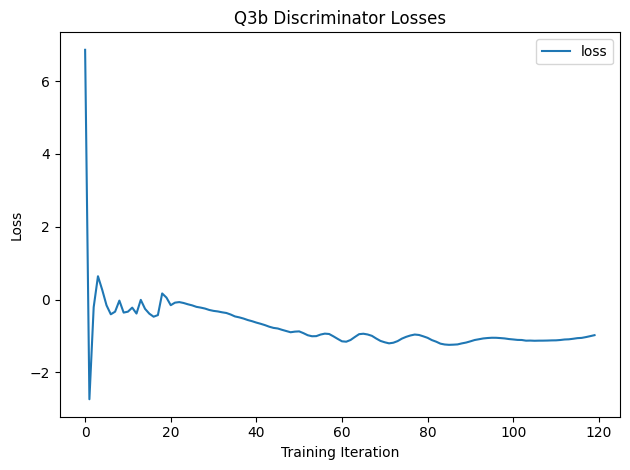

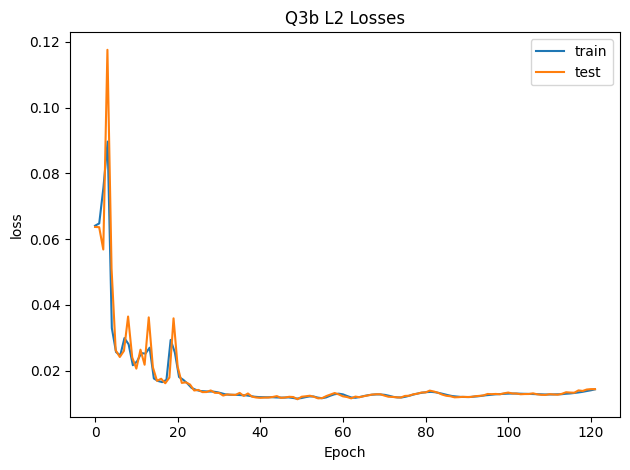

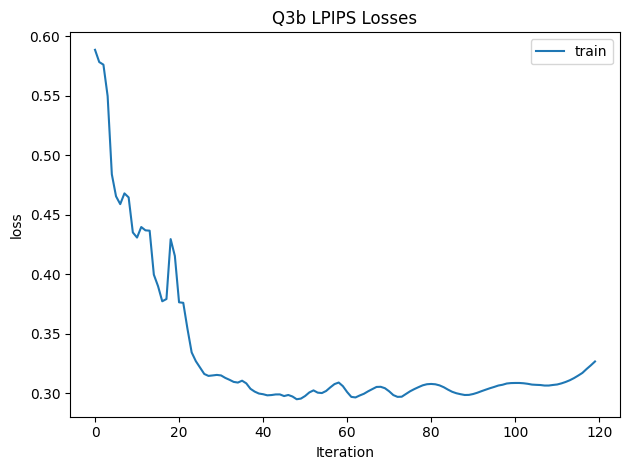

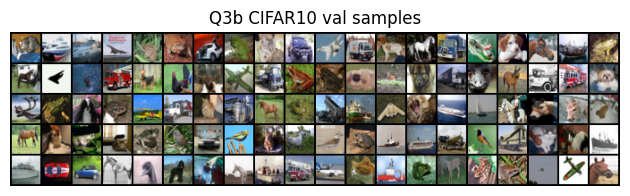

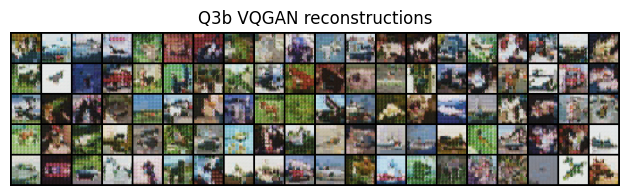

final_val_reconstruction_loss: 0.01436684664433739


In [57]:
q3_save_results(q3b, "b")

# Question 4 (Bonus): CycleGAN [20pt]
In this question, you'll train a CycleGAN model to learn to translate between two different image domains, without any paired data. Execute the following cell to visualize our two datasets: MNIST and Colored MNIST. 

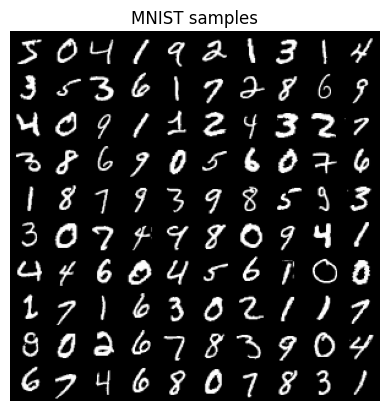

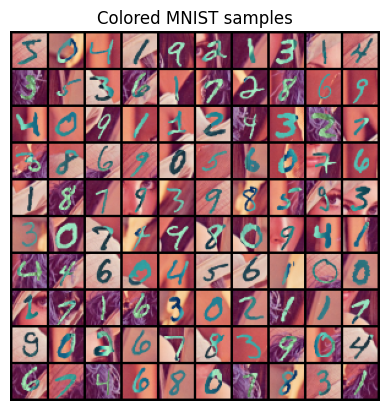

In [58]:
visualize_cyclegan_datasets()

In [CycleGAN](https://arxiv.org/pdf/1703.10593.pdf), the goal is to learn functions $F$ and $G$ that can transform images from $X \rightarrow Y$ and vice-versa. This is an unconstrained problem, so we additionally enforce the *cycle-consistency* property, where we want 
$$x \approx G(F(x))$$
and  
$$y \approx F(G(x))$$
This loss function encourages $F$ and $G$ to approximately invert each other. In addition to this cycle-consistency loss, we also have a standard GAN loss such that $F(x)$ and $G(y)$ look like real images from the other domain. 

Since this is a bonus question, we won't do much hand-holding. We recommend reading through the original paper to get a sense of what architectures and hyperparameters are useful. Note that our datasets are fairly simple, so you won't need excessively large models. 

**You will report the following deliverables**
1. A set of images showing real MNIST digits, transformations of those images into Colored MNIST digits, and reconstructions back into the greyscale domain. 
2. A set of images showing real Colored MNIST digits, transformations of those images, and reconstructions. 

## Solution

In [59]:
def q4(mnist_data, cmnist_data):
    """
    mnist_data: An (60000, 1, 28, 28) numpy array of black and white images with values in [0, 1]
    cmnist_data: An (60000, 3, 28, 28) numpy array of colored images with values in [0, 1]

    Returns
    - a (20, 28, 28, 1) numpy array of real MNIST digits, in [0, 1]
    - a (20, 28, 28, 3) numpy array of translated Colored MNIST digits, in [0, 1]
    - a (20, 28, 28, 1) numpy array of reconstructed MNIST digits, in [0, 1]

    - a (20, 28, 28, 3) numpy array of real Colored MNIST digits, in [0, 1]
    - a (20, 28, 28, 1) numpy array of translated MNIST digits, in [0, 1]
    - a (20, 28, 28, 3) numpy array of reconstructed Colored MNIST digits, in [0, 1]
    """
    """ YOUR CODE HERE """

## Results

In [60]:
q4_save_results(q4)

TypeError: cannot unpack non-iterable NoneType object